In [89]:
import numpy as np
import matplotlib.pyplot as plt

def bvn(x, y, xmean, ymean, cov=np.array([[1,0],[0,1]])): 
    '''
    calculates bivariate density at x,y given means and covariance matrix
    x,y are coordinates, default covariance is variance 1 for both and no covariance (independent x and y)
    '''
    xy = np.array([[x],[y]])
    mu = np.array([[xmean],[ymean]])
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    denom = np.sqrt(((2 * np.pi)**2) * det)
    num = np.e ** (-1/2 * (xy - mu).T @ inv @ (xy - mu))
    return (num/denom)[0][0] # index into a np.array([[v]]) to extract the value

def init_background_density(board, n):
    '''
    board = 2d grid
    uses bvn to stack n random gaussian distributions
    visualizes distribution at end via matplotlib imshow
    potential issues: can have lots of them stacked on top of each other
    '''
    board = np.copy(board)
    
    rng = np.random.default_rng()
    for dist in range(n):
        
        # generate a random center for the gaussian
        xmean = rng.integers(0, high=len(board[0])) # elements per row (number of columns)
        ymean = rng.integers(0, high=len(board)) # number of rows
        # uses circular bvns, x and y have same variance (can be changed)
        var = rng.integers(len(board)//4, high=len(board)//2)
        
        for (x,y), v in np.ndenumerate(board):
            board[x,y] += bvn(x,y, xmean, ymean, cov=np.array([[var,0],[0,var]]))
    
    plt.figure()
    plt.imshow(board)
    plt.colorbar()
    plt.show()
    return board

def get_targets(board, threshold):
    '''
    returns target locations if density is above a certain threshold
    may be useless
    '''
    targets = np.array([])
    for (x,y), v in np.ndenumerate(board):
        if v >= threshold:
            targets = np.append(targets, [x,y])
    return targets

def sample_agents(board, n):
    '''
    samples n agents from a board, assumes that not all values are zero
    uniform random sampling across board (does not weight based on background density...)
    can initiate multiple agents in the same grid space if grid space has a background density > 1
    '''
    agents = np.array([])
    violent_agent_count = 0
    rng = np.random.default_rng()
    x = rng.integers(0, high=len(board[0]), size=n) # elements per row (number of columns)
    y = rng.integers(0, high=len(board), size=n) # number of rows
    for i in range(n):
        a = Agent(x[i],y[i])
        # die roll
        if rng.integers(0, 10) > 5:
            a.violent_tendencies = True # 0.5 chance that they are violent
            if rng.integers(0,10) > 8:
                a.possesses_weapon = True # 0.2 chance that a violent agent already possesses a weapon
                violent_agent_count += 1
        agents = np.append(agents, a)
    print("num violent_agents=", violent_agent_count)
    return agents

def move_agent(board, agent):
    '''
    moves agent in a random walk by one space
    '''
    rng = np.random.default_rng()
    x = rng.integers(max(0, agent.x-1), high=min(len(board[0])-1, agent.x+1)+1)
    y = rng.integers(max(0, agent.y-1), high=min(len(board)-1, agent.y+1)+1)
    
    frac = board[agent.x, agent.y] / board.size
    board[agent.x, agent.y] -= frac
    agent.x = x
    agent.y = y
    board[x,y] += frac
    
    return board, agent

def agent_go_home(board, agent):
    '''
    reset agent position to their home coordinates
    '''
    frac = board[agent.x, agent.y] / board.size
    board[agent.x, agent.y] -= frac
    agent.x = agent.home_coordinates[0]
    agent.y = agent.home_coordinates[1]
    board[agent.x, agent.y] += frac
    
    return board, agent

def agent_initiate_event(board, agent, threshold):
    x = agent.x
    y = agent.y
    return (board[x,y] >= threshold) and agent.violent_tendencies and agent.possesses_weapon

# this could be represented as an array instead of a class: e.g np.array([x,y,0,0,x,y])
class Agent():
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.violent_tendencies = False
        self.possesses_weapon = False
        self.home_coordinates = np.array([x,y])        



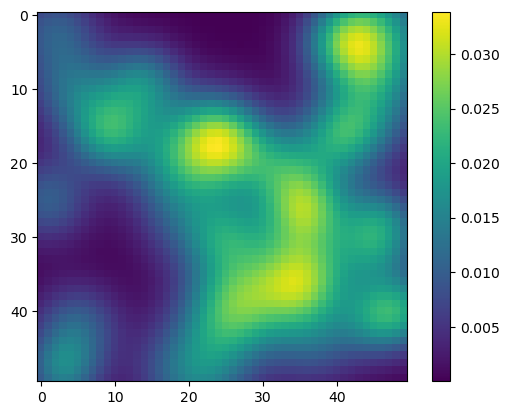

num violent_agents= 14


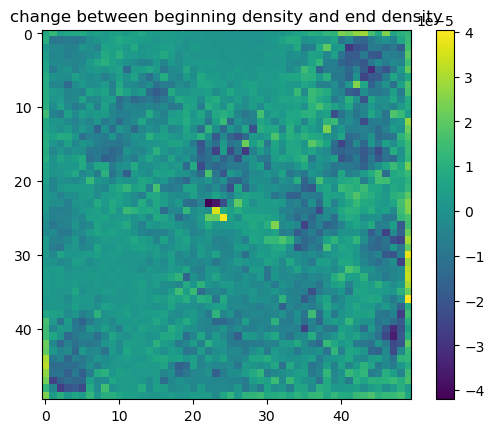

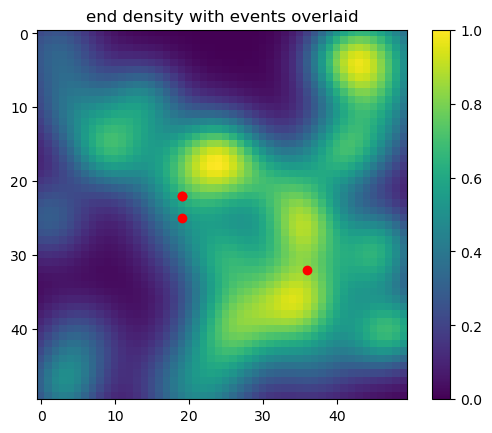

In [90]:
# tiny baby toy sim
from copy import deepcopy

board = np.zeros((50,50))
board = init_background_density(board, 40)
b = deepcopy(board)
agents = sample_agents(board, 250)
eventsx = np.array([])
eventsy = np.array([])
t = 500
for i in range(t):
    new_agents = np.array([])
    for a in agents:
        move_agent(board, a)
        if agent_initiate_event(board, a, np.max(b)/1.1):
            #print("event at ", a.x, " ", a.y)
            eventsx = np.append(eventsx, a.x)
            eventsy = np.append(eventsy, a.y)
        else:
            new_agents = np.append(new_agents, a)
    agents = new_agents # to ensure each agent can only initiate one event
    if t % 100 == 0:
        agent_go_home(board, a)
plt.figure()
plt.imshow(board - b)
plt.colorbar()
plt.title("change between beginning density and end density")
plt.show()

plt.figure()
plt.imshow(board)
plt.scatter(eventsx, eventsy, c='r')
plt.colorbar()
plt.title("end density with events overlaid")
plt.show()